# Module 2 — Anomaly Detection with Autoencoders
### Blocks 1–2 · MS Data Engineering

---

## 1 · What Is an Autoencoder?

An **autoencoder** (AE) is a neural network trained to copy its input to its output through a **bottleneck** — a low-dimensional intermediate representation called the **latent code** or **embedding**.

```
Input x  ──►  Encoder f_θ  ──►  z (latent)  ──►  Decoder g_φ  ──►  x̂ (reconstruction)
```

The training objective minimises the **reconstruction loss**:

$$\mathcal{L}_{\text{AE}} = \frac{1}{N}\sum_{i=1}^N \|x_i - \hat{x}_i\|^2$$

### Why does this detect anomalies?

The key insight is the **inductive bias of the bottleneck**:

- The model is trained on **normal data** only.
- The encoder learns to compress the patterns that are *common* in the training distribution.
- At inference time, **normal samples** lie on the learned manifold → small reconstruction error.
- **Anomalous samples** do not project well through the bottleneck → large reconstruction error.

$$\text{anomaly score}(x) = \|x - g_\phi(f_\theta(x))\|^2$$

A sample is flagged anomalous if its score exceeds a threshold $\tau$.

---

## 2 · Architecture Variants

| Variant | Encoder/Decoder | Bottleneck | Typical use |
|---|---|---|---|
| **Vanilla AE** | Dense MLP | Deterministic vector $z$ | Tabular data |
| **Conv AE** | CNN | Spatial feature map | Images |
| **LSTM-AE** | LSTM | Hidden state sequence | Time series |
| **VAE** | MLP + reparameterisation | Stochastic $z \sim \mathcal{N}(\mu, \sigma^2)$ | Generative + detection |

In this notebook we cover **Vanilla AE** and **VAE**. LSTM-AE is covered in Notebook 2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


## 3 · Dataset: Synthetic Tabular Data

We generate a dataset where:
- **Normal data** lives on a 2D elliptical manifold embedded in 20D.
- **Anomalies** are points drawn from a wider Gaussian (out-of-distribution).

This mimics realistic scenarios like network intrusion detection or sensor fault detection, where most observations follow a structured pattern and anomalies deviate structurally.

In [2]:
def make_dataset(n_normal=4000, n_anomaly=200, n_features=20, anomaly_fraction_test=0.1):
    """Synthetic dataset: normal = structured 2D manifold in 20D; anomalies = noise."""
    # Normal data: 2 latent factors + noise
    z = np.random.randn(n_normal + 500, 2)
    z[:, 0] *= 3   # elongated ellipse
    A = np.random.randn(2, n_features) * 0.5  # random projection
    X_normal = z @ A + np.random.randn(n_normal + 500, n_features) * 0.3

    # Anomalies: uniform in a much larger range
    X_anomaly = np.random.randn(n_anomaly, n_features) * 4.0

    # Scale
    scaler = StandardScaler()
    X_all = np.vstack([X_normal, X_anomaly])
    X_all = scaler.fit_transform(X_all)
    X_normal_s = X_all[:len(X_normal)]
    X_anomaly_s = X_all[len(X_normal):]

    # Train: only normal
    X_train = X_normal_s[:n_normal]
    # Test: mix
    n_test_normal = 500
    X_test = np.vstack([X_normal_s[n_normal:], X_anomaly_s])
    y_test = np.array([0]*n_test_normal + [1]*n_anomaly)

    return X_train.astype(np.float32), X_test.astype(np.float32), y_test

X_train, X_test, y_test = make_dataset()
print(f'Train (normal only): {X_train.shape}')
print(f'Test  (mixed):       {X_test.shape}  |  anomaly rate: {y_test.mean():.1%}')

Train (normal only): (4000, 20)
Test  (mixed):       (700, 20)  |  anomaly rate: 28.6%


### 3.1 · Quick Peek: PCA of the Dataset

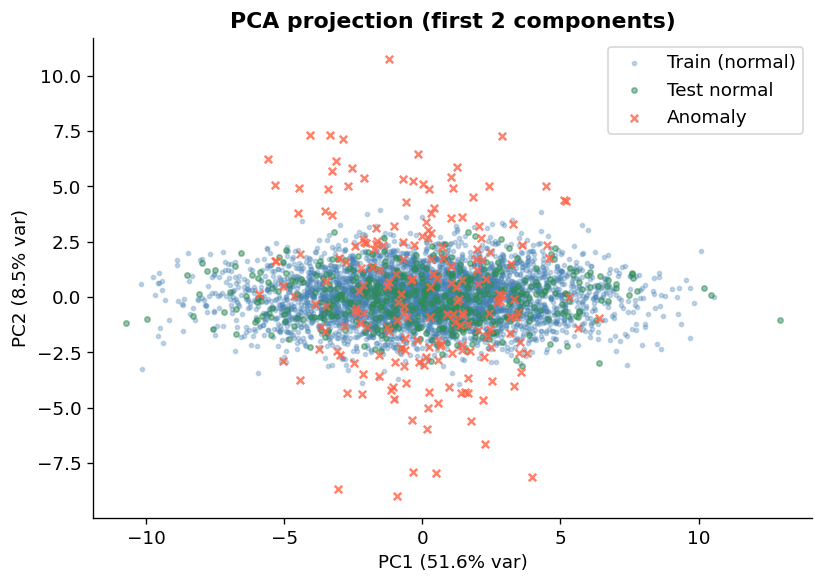

In [3]:
pca = PCA(n_components=2)
X_all_2d = pca.fit_transform(np.vstack([X_train, X_test]))
X_train_2d = X_all_2d[:len(X_train)]
X_test_normal_2d = X_all_2d[len(X_train):len(X_train) + (y_test == 0).sum()]
X_test_anom_2d   = X_all_2d[len(X_train) + (y_test == 0).sum():]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(*X_train_2d.T,       s=6,  alpha=0.3, color='steelblue',  label='Train (normal)')
ax.scatter(*X_test_normal_2d.T, s=10, alpha=0.5, color='seagreen',   label='Test normal')
ax.scatter(*X_test_anom_2d.T,   s=20, alpha=0.8, color='tomato',     label='Anomaly', marker='x')
ax.set_title('PCA projection (first 2 components)', fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/pca_dataset.png', bbox_inches='tight')
plt.show()

## 4 · Vanilla Autoencoder

### Architecture Diagram

```
Input (20)  →  Dense(64) →ReLU→  Dense(32) →ReLU→  z(8)
                                                       ↓
Output(20)  ←  Dense(64) ←ReLU←  Dense(32) ←ReLU←  Dense(8)
```

**Bottleneck dimension** controls the trade-off:
- Too small → underfitting, even normal samples reconstruct poorly.
- Too large → overfitting, anomalies also reconstruct well (no discrimination).
- A good bottleneck forces the model to learn the *essential structure* of normal data.

In [4]:
class VanillaAE(nn.Module):
    def __init__(self, input_dim, latent_dim=8, hidden_dims=(64, 32)):
        super().__init__()
        # Encoder
        enc_layers = []
        prev = input_dim
        for h in hidden_dims:
            enc_layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        enc_layers.append(nn.Linear(prev, latent_dim))
        self.encoder = nn.Sequential(*enc_layers)

        # Decoder (mirrors encoder)
        dec_layers = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            dec_layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        dec_layers.append(nn.Linear(prev, input_dim))
        self.decoder = nn.Sequential(*dec_layers)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

    def reconstruction_error(self, x):
        with torch.no_grad():
            x_hat, _ = self.forward(x)
            return ((x - x_hat) ** 2).mean(dim=1).cpu().numpy()


def train_ae(model, X_train, epochs=60, batch_size=256, lr=1e-3):
    model.to(DEVICE)
    dataset = TensorDataset(torch.tensor(X_train))
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    opt     = optim.Adam(model.parameters(), lr=lr)
    losses  = []
    for ep in range(epochs):
        ep_loss = 0
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            x_hat, _ = model(xb)
            loss = nn.MSELoss()(x_hat, xb)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_loss += loss.item() * len(xb)
        losses.append(ep_loss / len(X_train))
        if (ep + 1) % 20 == 0:
            print(f'  Epoch {ep+1:3d}/{epochs}  loss={losses[-1]:.5f}')
    return losses

ae = VanillaAE(input_dim=20, latent_dim=8)
print('Training Vanilla AE...')
ae_losses = train_ae(ae, X_train)

Training Vanilla AE...
  Epoch  20/60  loss=0.04672
  Epoch  40/60  loss=0.04109
  Epoch  60/60  loss=0.03141


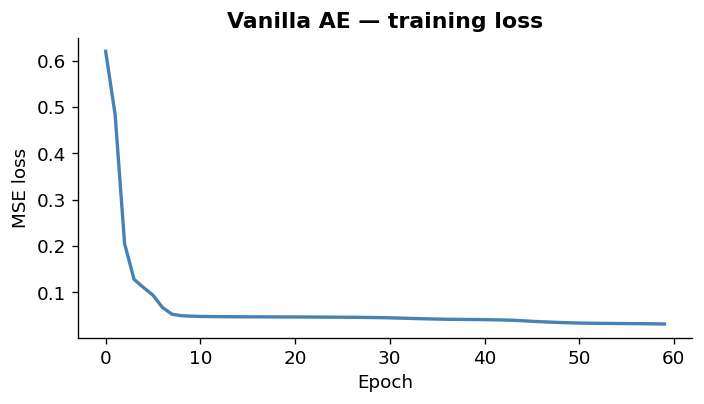

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(ae_losses, color='steelblue', lw=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('Vanilla AE — training loss', fontweight='bold')
plt.tight_layout()
plt.show()

## 5 · Anomaly Scoring and Thresholding

### 5.1 · Reconstruction Error Distribution

We expect a clear separation between the reconstruction error distributions of normal vs anomalous samples. A **threshold $\tau$** is set on this score.

**Common threshold strategies:**
- **Percentile of training errors:** $\tau = Q_{95}(\text{scores on train set})$
- **Mean + k·std:** $\tau = \mu_{\text{train}} + k\sigma_{\text{train}}$
- **Grid search on a labelled validation set** (when available)
- **Extreme Value Theory (EVT):** model the tail of the train score distribution

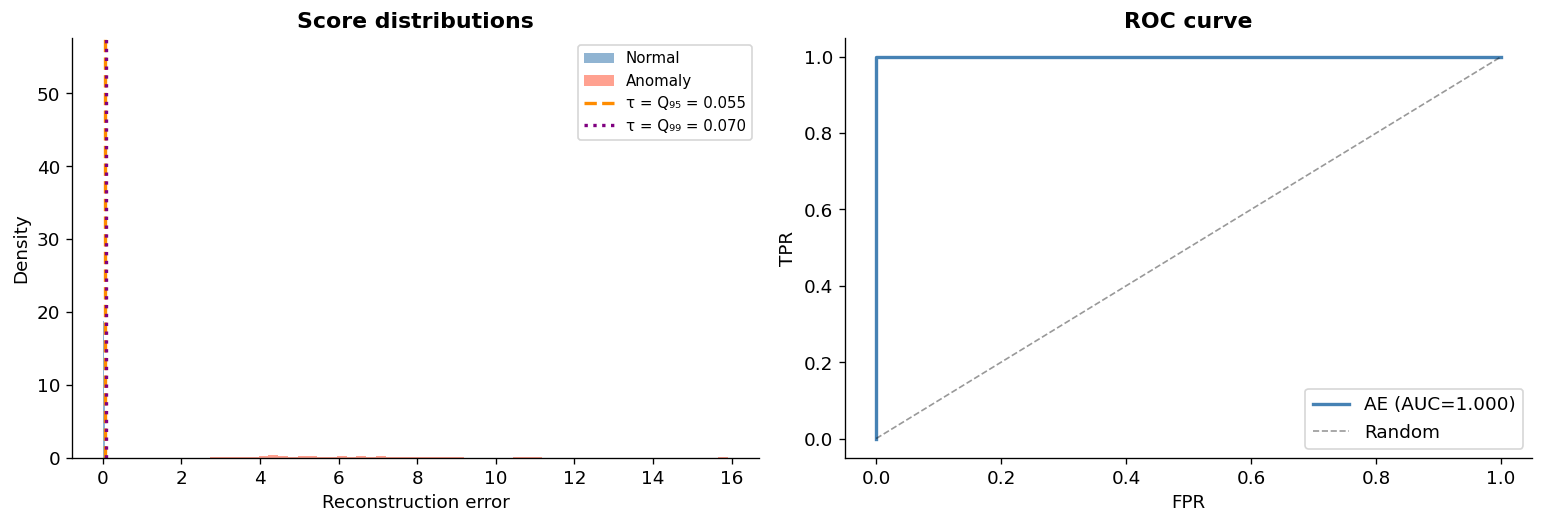

AUC-ROC: 1.0000


In [6]:
ae.eval()
X_test_t  = torch.tensor(X_test).to(DEVICE)
X_train_t = torch.tensor(X_train).to(DEVICE)

scores_test  = ae.reconstruction_error(X_test_t)
scores_train = ae.reconstruction_error(X_train_t)

scores_normal = scores_test[y_test == 0]
scores_anom   = scores_test[y_test == 1]

# Threshold: 95th percentile of training reconstruction errors
tau_95 = np.percentile(scores_train, 95)
tau_99 = np.percentile(scores_train, 99)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: Score distributions ---
ax = axes[0]
ax.hist(scores_normal, bins=60, alpha=0.6, color='steelblue', density=True, label='Normal')
ax.hist(scores_anom,   bins=60, alpha=0.6, color='tomato',   density=True, label='Anomaly')
ax.axvline(tau_95, color='darkorange', lw=2, ls='--', label=f'τ = Q₉₅ = {tau_95:.3f}')
ax.axvline(tau_99, color='purple',     lw=2, ls=':',  label=f'τ = Q₉₉ = {tau_99:.3f}')
ax.set_xlabel('Reconstruction error')
ax.set_ylabel('Density')
ax.set_title('Score distributions', fontweight='bold')
ax.legend(fontsize=9)

# --- Right: ROC curve ---
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, scores_test)
auc = roc_auc_score(y_test, scores_test)
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AE (AUC={auc:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC curve', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('/tmp/ae_scores.png', bbox_inches='tight')
plt.show()
print(f'AUC-ROC: {auc:.4f}')

### 5.2 · Precision–Recall Curve

With imbalanced classes (typical in anomaly detection), the **PR curve** is often more informative than ROC, since it focuses on the minority class.

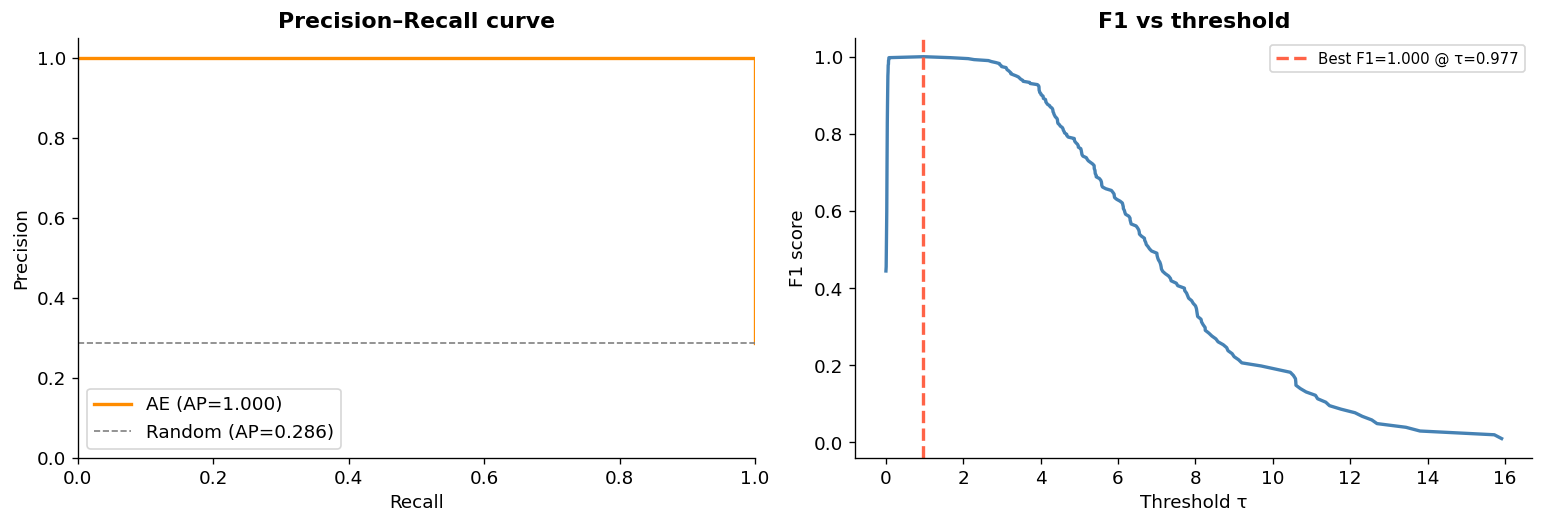

Best F1: 1.0000 at τ = 0.9770


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- PR curve ---
ax = axes[0]
prec, rec, thresholds = precision_recall_curve(y_test, scores_test)
ap = average_precision_score(y_test, scores_test)
ax.plot(rec, prec, color='darkorange', lw=2, label=f'AE (AP={ap:.3f})')
baseline = y_test.mean()
ax.axhline(baseline, color='gray', lw=1, ls='--', label=f'Random (AP={baseline:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision–Recall curve', fontweight='bold')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.legend()

# --- F1 vs Threshold ---
ax = axes[1]
f1_scores = 2*prec[:-1]*rec[:-1] / (prec[:-1]+rec[:-1]+1e-9)
best_idx = f1_scores.argmax()
ax.plot(thresholds, f1_scores, color='steelblue', lw=2)
ax.axvline(thresholds[best_idx], color='tomato', lw=2, ls='--',
           label=f'Best F1={f1_scores[best_idx]:.3f} @ τ={thresholds[best_idx]:.3f}')
ax.set_xlabel('Threshold τ'); ax.set_ylabel('F1 score')
ax.set_title('F1 vs threshold', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f'Best F1: {f1_scores[best_idx]:.4f} at τ = {thresholds[best_idx]:.4f}')

### 5.3 · Latent Space Visualisation

With a bottleneck of dimension 8, we project latent codes to 2D via PCA to inspect clustering.

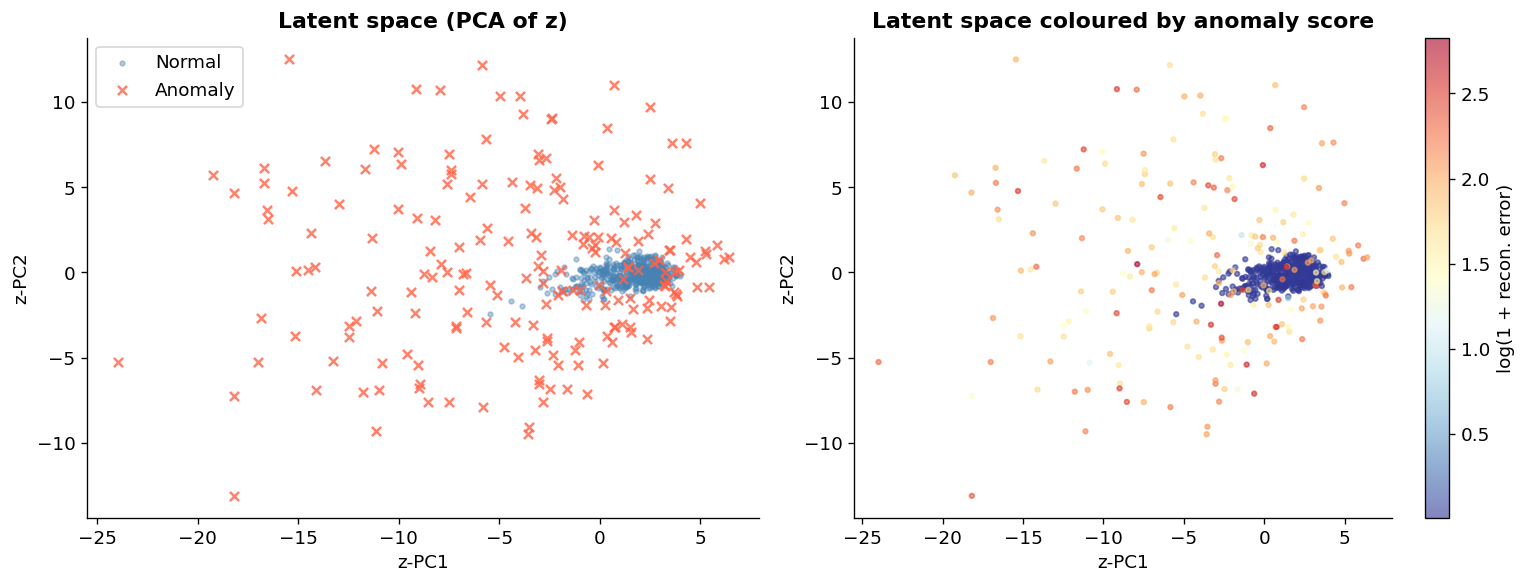

In [8]:
with torch.no_grad():
    _, z_test = ae(X_test_t)
z_test_np = z_test.cpu().numpy()

pca_z = PCA(n_components=2)
z_2d = pca_z.fit_transform(z_test_np)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(z_2d[y_test==0, 0], z_2d[y_test==0, 1], s=8,  alpha=0.4, c='steelblue', label='Normal')
ax.scatter(z_2d[y_test==1, 0], z_2d[y_test==1, 1], s=30, alpha=0.8, c='tomato',    label='Anomaly', marker='x')
ax.set_title('Latent space (PCA of z)', fontweight='bold')
ax.set_xlabel('z-PC1'); ax.set_ylabel('z-PC2')
ax.legend()

# Colour by reconstruction error
ax = axes[1]
sc = ax.scatter(z_2d[:, 0], z_2d[:, 1], s=8, c=np.log1p(scores_test),
                cmap='RdYlBu_r', alpha=0.6)
plt.colorbar(sc, ax=ax, label='log(1 + recon. error)')
ax.set_title('Latent space coloured by anomaly score', fontweight='bold')
ax.set_xlabel('z-PC1'); ax.set_ylabel('z-PC2')
plt.tight_layout()
plt.savefig('/tmp/latent_space.png', bbox_inches='tight')
plt.show()

## 6 · Effect of Bottleneck Dimension

A core claim of the AE-based anomaly detection theory is that the latent dimension $d_z$ controls a **bias–variance trade-off**:

- $d_z$ **too small** → the AE underfits even the normal manifold; reconstruction error is large for *everything*, so normal and anomalous samples are no longer separable.
- $d_z$ **too large** → the AE has enough capacity to behave like the identity map, reconstructing anomalies as well as normal points; once again, the two distributions become indistinguishable.
- $d_z$ **at the right scale** (close to the *intrinsic* dimension of the normal data) → the AE captures the normal manifold but fails on off-manifold anomalies → maximal separation.

### Why the naïve sweep is uninformative here

If we sweep $d_z$ on the dataset of Section 3 (clean training, far-out-of-distribution anomalies), we observe an almost flat curve. The reason is twofold:

1. The normal manifold has intrinsic dimension $\approx 2$, so any $d_z \ge 2$ already covers it.
2. The anomalies are drawn from a much wider distribution ($\sigma_{\text{anom}} \approx 4 \cdot \sigma_{\text{norm}}$); they are so far from the normal manifold that *no* bottleneck within the practical range can reconstruct them. The overfitting regime is never reached.

A meaningful experiment must place the anomalies somewhere the AE can plausibly learn to reconstruct — e.g.\ on a *different* low-dimensional manifold of comparable variance. The textbook trade-off then becomes visible, especially when the training set contains a small fraction of contaminating anomalies (the realistic case in deployed systems where labels are imperfect).

### Experimental design

We compare two training regimes on a redesigned dataset:
- **Clean** ($0\%$ contamination): normal training data only.
- **Contaminated** ($3\%$ contamination): a small number of anomalous samples are mixed into the training set.

For each regime, we sweep $d_z \in \{1, 2, 3, 5, 8, 12, 16\}$, train the AE three times with different seeds, and report the mean AUC-ROC together with the average reconstruction error on normal vs anomalous test samples (the latter exposes the *mechanism* behind the AUC curve).


In [9]:
def make_dataset_bottleneck(n_normal=4000, n_anomaly=200, n_features=20,
                            anomaly_train_frac=0.0, seed=42):
    """
    Dataset designed to expose the bottleneck trade-off.

    - Normal data: 2D latent manifold in 20D (same family as Section 3).
    - Anomalies:   3D latent manifold in a DIFFERENT random subspace,
                   with variance comparable to normals (NOT far-out-of-distribution).
                   This means a sufficiently large AE can learn to reconstruct them.
    - If anomaly_train_frac > 0, contaminate the training set with that fraction
      of anomalies (realistic setting: labels in real-world data are imperfect).
    """
    rng = np.random.RandomState(seed)
    # Normal — 2D latent (one elongated direction), as in Section 3
    z = rng.randn(n_normal + 500, 2); z[:, 0] *= 3
    A_n = rng.randn(2, n_features) * 0.5
    X_normal = z @ A_n + rng.randn(n_normal + 500, n_features) * 0.3
    # Anomalies — 3D latent in a different random subspace, comparable scale
    n_anom_train = int(anomaly_train_frac * n_normal / max(1 - anomaly_train_frac, 1e-6))
    n_anom_total = n_anomaly + n_anom_train
    A_a = rng.randn(3, n_features) * 0.5
    z_a = rng.randn(n_anom_total, 3) * 1.5
    X_anomaly = z_a @ A_a + rng.randn(n_anom_total, n_features) * 0.3

    scaler = StandardScaler()
    X_all = scaler.fit_transform(np.vstack([X_normal, X_anomaly]))
    Xn, Xa = X_all[:len(X_normal)], X_all[len(X_normal):]

    if n_anom_train > 0:
        X_tr = np.vstack([Xn[:n_normal], Xa[:n_anom_train]])
        X_tr = X_tr[np.random.RandomState(0).permutation(len(X_tr))]
    else:
        X_tr = Xn[:n_normal]
    X_te = np.vstack([Xn[n_normal:n_normal + 500], Xa[-n_anomaly:]])
    y_te = np.array([0] * 500 + [1] * n_anomaly)
    return X_tr.astype(np.float32), X_te.astype(np.float32), y_te


def sweep_bottleneck(latent_dims, anomaly_train_frac, n_seeds=3, epochs=60):
    """Train an AE at each latent_dim, n_seeds times; collect AUC and per-class recon."""
    X_tr, X_te, y_te = make_dataset_bottleneck(anomaly_train_frac=anomaly_train_frac)
    X_te_t = torch.tensor(X_te).to(DEVICE)
    out = {d: {"auc": [], "rec_n": [], "rec_a": []} for d in latent_dims}
    for d in latent_dims:
        for s in range(n_seeds):
            torch.manual_seed(s)
            m = VanillaAE(input_dim=20, latent_dim=d)
            train_ae(m, X_tr, epochs=epochs, batch_size=256)
            m.eval()
            sc = m.reconstruction_error(X_te_t)
            out[d]["auc"].append(roc_auc_score(y_te, sc))
            out[d]["rec_n"].append(sc[y_te == 0].mean())
            out[d]["rec_a"].append(sc[y_te == 1].mean())
    return out


latent_dims = [1, 2, 3, 5, 8, 12, 16]
print('Sweeping bottleneck dimensions — clean training...')
sweep_clean = sweep_bottleneck(latent_dims, anomaly_train_frac=0.0)
print('Sweeping bottleneck dimensions — 3% contamination...')
sweep_contam = sweep_bottleneck(latent_dims, anomaly_train_frac=0.03)

for label, sweep in [('clean', sweep_clean), ('contam 3%', sweep_contam)]:
    print(f'\n--- {label} ---')
    for d in latent_dims:
        a = sweep[d]
        print(f'  d_z={d:2d}  AUC={np.mean(a["auc"]):.3f}±{np.std(a["auc"]):.3f}  '
              f'rec(N)={np.mean(a["rec_n"]):.3f}  rec(A)={np.mean(a["rec_a"]):.3f}')


Sweeping bottleneck dimensions — clean training...
  Epoch  20/60  loss=0.23506
  Epoch  40/60  loss=0.23449
  Epoch  60/60  loss=0.22913
  Epoch  20/60  loss=0.23508
  Epoch  40/60  loss=0.23485
  Epoch  60/60  loss=0.23460
  Epoch  20/60  loss=0.23490
  Epoch  40/60  loss=0.23463
  Epoch  60/60  loss=0.23414
  Epoch  20/60  loss=0.12031
  Epoch  40/60  loss=0.11964
  Epoch  60/60  loss=0.11935
  Epoch  20/60  loss=0.12027
  Epoch  40/60  loss=0.11965
  Epoch  60/60  loss=0.11936
  Epoch  20/60  loss=0.12009
  Epoch  40/60  loss=0.11961
  Epoch  60/60  loss=0.11943
  Epoch  20/60  loss=0.10035
  Epoch  40/60  loss=0.08996
  Epoch  60/60  loss=0.08949
  Epoch  20/60  loss=0.11908
  Epoch  40/60  loss=0.09056
  Epoch  60/60  loss=0.08958
  Epoch  20/60  loss=0.11761
  Epoch  40/60  loss=0.09017
  Epoch  60/60  loss=0.08960
  Epoch  20/60  loss=0.10886
  Epoch  40/60  loss=0.07494
  Epoch  60/60  loss=0.06016
  Epoch  20/60  loss=0.11626
  Epoch  40/60  loss=0.06664
  Epoch  60/60  loss=

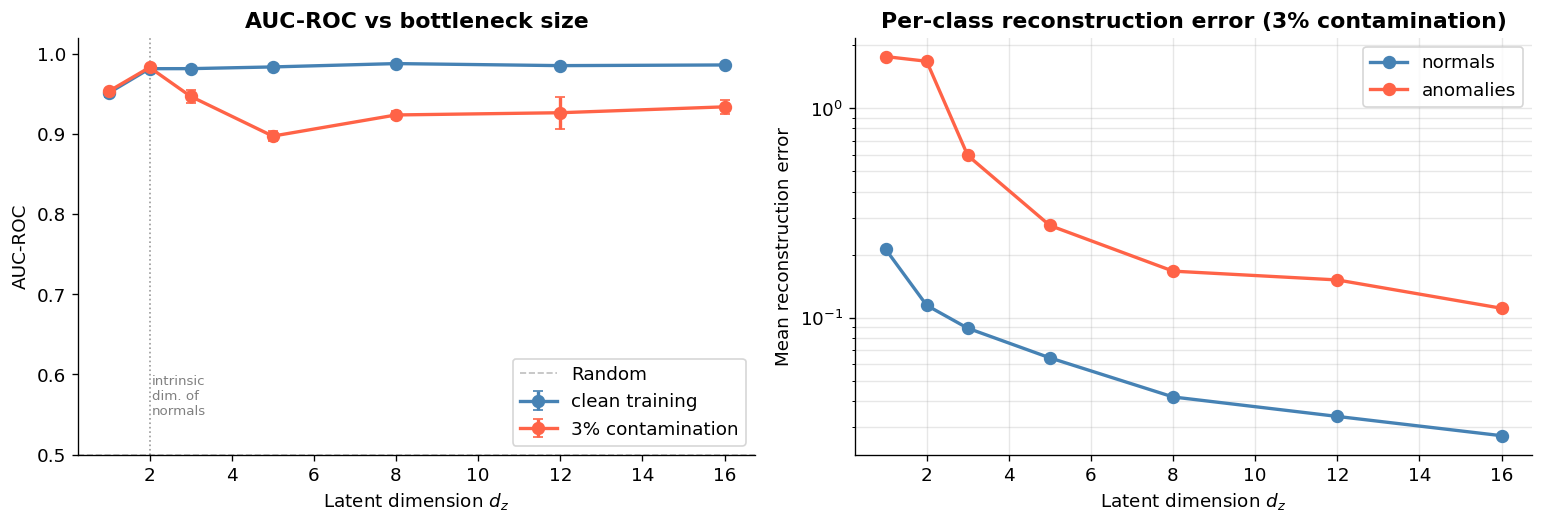

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: AUC vs d_z, clean vs contaminated ---
ax = axes[0]
for sweep, label, color in [(sweep_clean,  'clean training',     'steelblue'),
                            (sweep_contam, '3% contamination',   'tomato')]:
    means = [np.mean(sweep[d]["auc"]) for d in latent_dims]
    stds  = [np.std(sweep[d]["auc"])  for d in latent_dims]
    ax.errorbar(latent_dims, means, yerr=stds, fmt='o-', lw=2, ms=7,
                color=color, label=label, capsize=3)
ax.set_xlabel('Latent dimension $d_z$')
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC vs bottleneck size', fontweight='bold')
ax.set_ylim(0.5, 1.02)
ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.5, label='Random')
ax.axvline(2, color='black', ls=':', lw=1, alpha=0.4)
ax.text(2.05, 0.55, 'intrinsic\ndim. of\nnormals', fontsize=8, color='gray')
ax.legend()

# --- Right: per-class reconstruction error (contaminated case) ---
ax = axes[1]
rec_n = [np.mean(sweep_contam[d]["rec_n"]) for d in latent_dims]
rec_a = [np.mean(sweep_contam[d]["rec_a"]) for d in latent_dims]
ax.plot(latent_dims, rec_n, 'o-', color='steelblue', lw=2, ms=7, label='normals')
ax.plot(latent_dims, rec_a, 'o-', color='tomato',    lw=2, ms=7, label='anomalies')
ax.set_xlabel('Latent dimension $d_z$')
ax.set_ylabel('Mean reconstruction error')
ax.set_yscale('log')
ax.set_title('Per-class reconstruction error (3% contamination)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('/tmp/latent_sweep.png', bbox_inches='tight')
plt.show()


### Interpretation

**Clean training** (blue curve): once $d_z \ge 2$ (the intrinsic dimension of the normal manifold), the AUC plateaus near $0.98$. Increasing $d_z$ further has almost no effect — the anomalies are simply too different from the normal manifold for any practical-sized bottleneck to reconstruct them. The textbook "overfitting" regime is invisible in this setting.

**Contaminated training** (red curve): a U-shape (or, more precisely, a peaked shape) emerges:
- $d_z = 1$: underfitting; even normal data is poorly reconstructed.
- $d_z = 2$: the sweet spot — the AE captures *only* the dominant (normal) manifold, ignoring the small anomalous minority.
- $d_z \ge 3$: the AE has enough capacity to also reconstruct the contaminating anomalies. The right-hand panel shows the mechanism explicitly: the mean reconstruction error on anomalies collapses by an order of magnitude as $d_z$ grows, while the error on normals continues to decrease only slightly. The two distributions overlap, AUC drops.

### Take-aways

1. The bottleneck trade-off is a **statement about the AE's capacity to memorise the training distribution**. It only becomes observable when (a) the AE *can* approach the identity map at large $d_z$, and (b) anomalies are similar enough to *some* component of the training distribution that they are at risk of being memorised.
2. **Training-set contamination amplifies the trade-off.** With even a few percent of anomalies in the training set, an over-sized bottleneck transforms the AE from a detector into a memoriser. In practice this argues for *small* bottlenecks and for explicit decontamination of the training set (e.g.\ iterative refinement: train, score, drop top-$k\%$, retrain).
3. The right diagnostic is **not just AUC**, but the **per-class reconstruction error gap** $\overline{\text{err}}_{\text{anom}} / \overline{\text{err}}_{\text{norm}}$. A shrinking gap is the early-warning signal of memorisation, often visible before AUC has noticeably degraded.


## 7 · Variational Autoencoder (VAE)

### Theory

A **Variational Autoencoder** (Kingma & Welling, 2014) extends the vanilla AE by making the latent space **probabilistic**.

Instead of encoding $x$ to a single point $z$, the encoder outputs the **parameters of a Gaussian distribution**:

$$q_\theta(z | x) = \mathcal{N}\bigl(\mu_\theta(x),\; \text{diag}(\sigma_\theta^2(x))\bigr)$$

The decoder reconstructs from a **sample** $z \sim q_\theta(z|x)$ (using the **reparameterisation trick** to allow backpropagation):

$$z = \mu_\theta(x) + \epsilon \odot \sigma_\theta(x), \qquad \epsilon \sim \mathcal{N}(0, I)$$

The training objective is the **ELBO** (Evidence Lower Bound):

$$\mathcal{L}_{\text{VAE}} = \underbrace{\mathbb{E}_{q}[\log p_\phi(x|z)]}_{\text{reconstruction}} - \underbrace{\text{KL}\bigl(q_\theta(z|x) \| p(z)\bigr)}_{\text{regularisation}}$$

The KL term encourages the posterior to stay close to the standard normal prior $p(z) = \mathcal{N}(0, I)$.

### Anomaly score for VAE

Two common options:
1. **Reconstruction probability:** $-\log p_\phi(x|z)$ ← this is just MSE for Gaussian decoder.
2. **ELBO score:** reconstruction loss + KL divergence (captures both reconstruction quality *and* how far the encoded distribution is from the prior).

$$\text{anomaly score}(x) = \|x - \hat{x}\|^2 + \text{KL}(q(z|x) \| p(z))$$

In [11]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=8, hidden_dims=(64, 32)):
        super().__init__()
        # Shared encoder backbone
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        self.encoder_backbone = nn.Sequential(*layers)
        self.fc_mu  = nn.Linear(prev, latent_dim)
        self.fc_log_var = nn.Linear(prev, latent_dim)

        # Decoder
        dec_layers = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            dec_layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        dec_layers.append(nn.Linear(prev, input_dim))
        self.decoder = nn.Sequential(*dec_layers)

    def encode(self, x):
        h = self.encoder_backbone(x)
        return self.fc_mu(h), self.fc_log_var(h)

    def reparameterise(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterise(mu, log_var)
        return self.decoder(z), mu, log_var

    def anomaly_score(self, x, n_samples=10):
        """ELBO-based anomaly score (averaged over multiple samples for stability)."""
        with torch.no_grad():
            mu, log_var = self.encode(x)
            # KL divergence: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
            kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)
            # Reconstruction (average over samples)
            recon = torch.zeros(x.size(0)).to(DEVICE)
            for _ in range(n_samples):
                z = self.reparameterise(mu, log_var)
                x_hat = self.decoder(z)
                recon += ((x - x_hat) ** 2).mean(dim=1)
            recon /= n_samples
        return (recon + kl).cpu().numpy()


def vae_loss(x, x_hat, mu, log_var, beta=1.0):
    recon = nn.MSELoss(reduction='sum')(x_hat, x) / x.size(0)
    kl    = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    return recon + beta * kl, recon.item(), kl.item()


def train_vae(model, X_train, epochs=80, batch_size=256, lr=1e-3, beta=1.0):
    model.to(DEVICE)
    dataset = TensorDataset(torch.tensor(X_train))
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    opt     = optim.Adam(model.parameters(), lr=lr)
    history = {'loss':[], 'recon':[], 'kl':[]}
    for ep in range(epochs):
        ep_loss = ep_recon = ep_kl = 0
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            x_hat, mu, log_var = model(xb)
            loss, r, k = vae_loss(xb, x_hat, mu, log_var, beta)
            opt.zero_grad(); loss.backward(); opt.step()
            n = len(xb)
            ep_loss += loss.item()*n; ep_recon += r*n; ep_kl += k*n
        N = len(X_train)
        history['loss'].append(ep_loss/N)
        history['recon'].append(ep_recon/N)
        history['kl'].append(ep_kl/N)
        if (ep + 1) % 20 == 0:
            print(f'  Epoch {ep+1:3d}  loss={ep_loss/N:.4f}  recon={ep_recon/N:.4f}  kl={ep_kl/N:.4f}')
    return history

vae = VAE(input_dim=20, latent_dim=8)
print('Training VAE...')
vae_hist = train_vae(vae, X_train)

Training VAE...
  Epoch  20  loss=1.9998  recon=1.2746  kl=0.7252
  Epoch  40  loss=1.7350  recon=1.1562  kl=0.5789
  Epoch  60  loss=1.6013  recon=1.0856  kl=0.5157
  Epoch  80  loss=1.5846  recon=1.0759  kl=0.5088


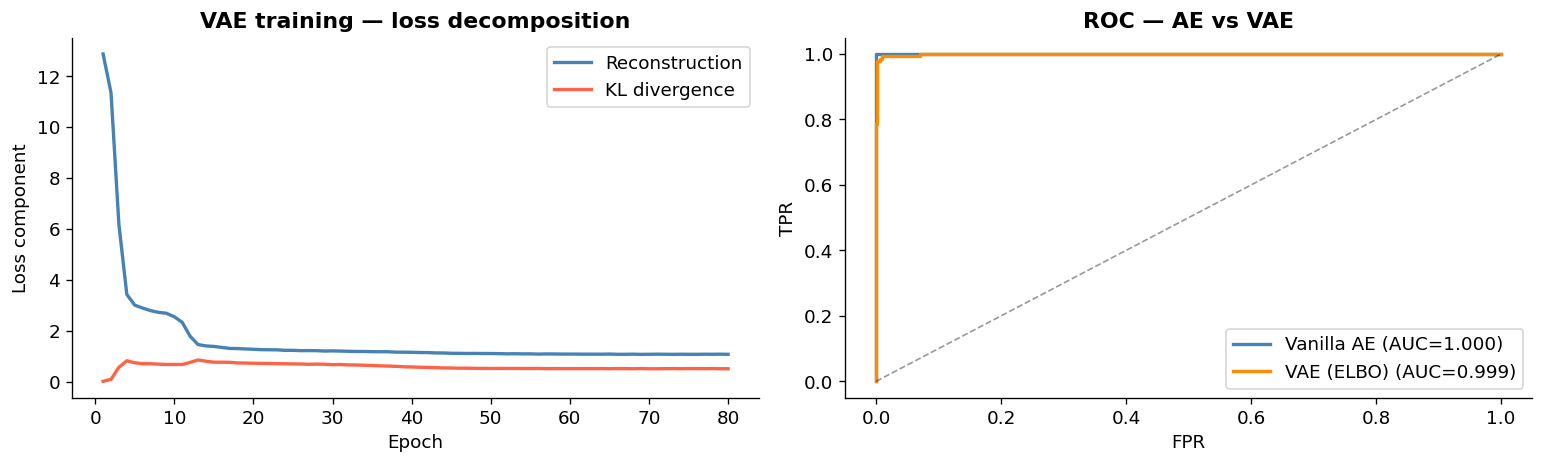

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Training curves
ax = axes[0]
eps = range(1, len(vae_hist['loss'])+1)
ax.plot(eps, vae_hist['recon'], label='Reconstruction', color='steelblue', lw=2)
ax.plot(eps, vae_hist['kl'],    label='KL divergence',  color='tomato',    lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss component')
ax.set_title('VAE training — loss decomposition', fontweight='bold')
ax.legend()

# Compare AE vs VAE ROC
vae.eval()
scores_vae = vae.anomaly_score(X_test_t)
scores_ae  = ae.reconstruction_error(X_test_t)

ax = axes[1]
for scores, label, color in [(scores_ae,  'Vanilla AE', 'steelblue'),
                              (scores_vae, 'VAE (ELBO)', 'darkorange')]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{label} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — AE vs VAE', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/vae_comparison.png', bbox_inches='tight')
plt.show()

### 7.1 · Latent Space Structure: AE vs VAE

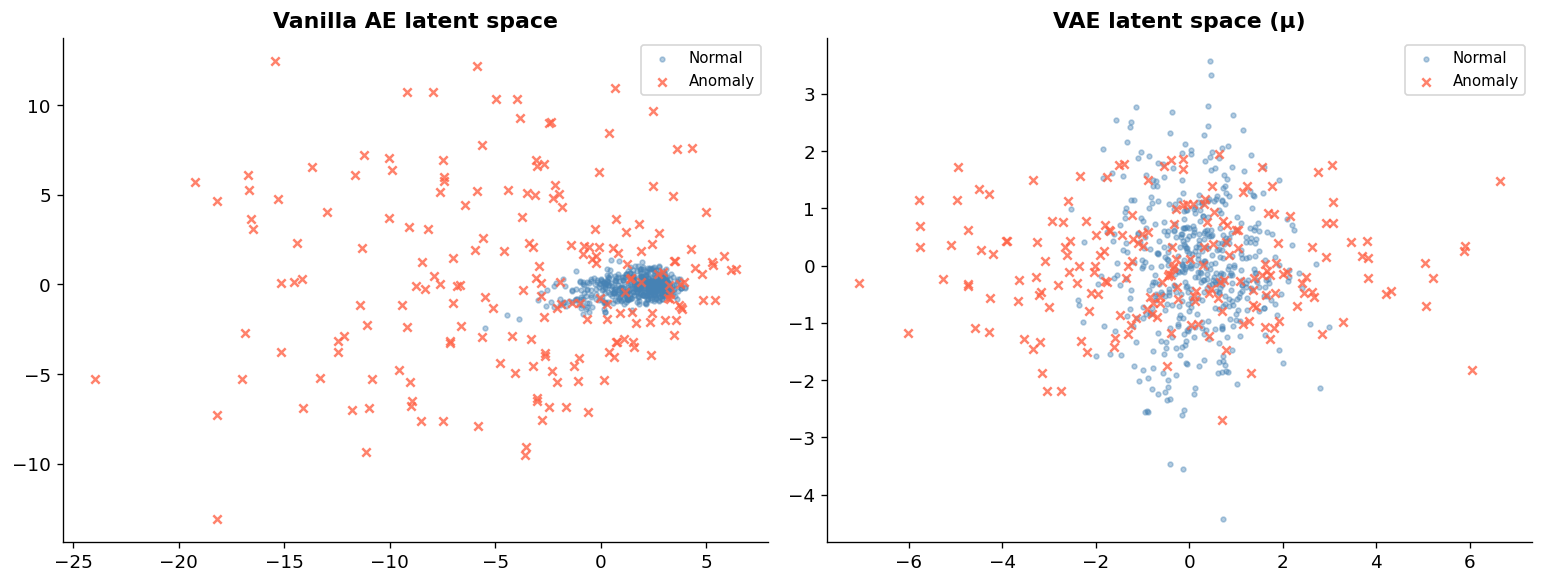

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, title in [(axes[0], ae, 'Vanilla AE latent space'),
                          (axes[1], vae, 'VAE latent space (μ)')]:
    with torch.no_grad():
        if isinstance(model, VAE):
            mu, _ = model.encode(X_test_t)
            z = mu.cpu().numpy()
        else:
            _, z = model(X_test_t)
            z = z.cpu().numpy()
    z2 = PCA(n_components=2).fit_transform(z)
    ax.scatter(z2[y_test==0,0], z2[y_test==0,1], s=8,  alpha=0.4, c='steelblue', label='Normal')
    ax.scatter(z2[y_test==1,0], z2[y_test==1,1], s=25, alpha=0.8, c='tomato',    label='Anomaly', marker='x')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/tmp/latent_comparison.png', bbox_inches='tight')
plt.show()

## 8 · Reconstruction Visualisation

For the test set, we visually compare the input vs reconstruction for a few normal and anomalous samples. This gives intuition about *what* the model struggles to reconstruct.

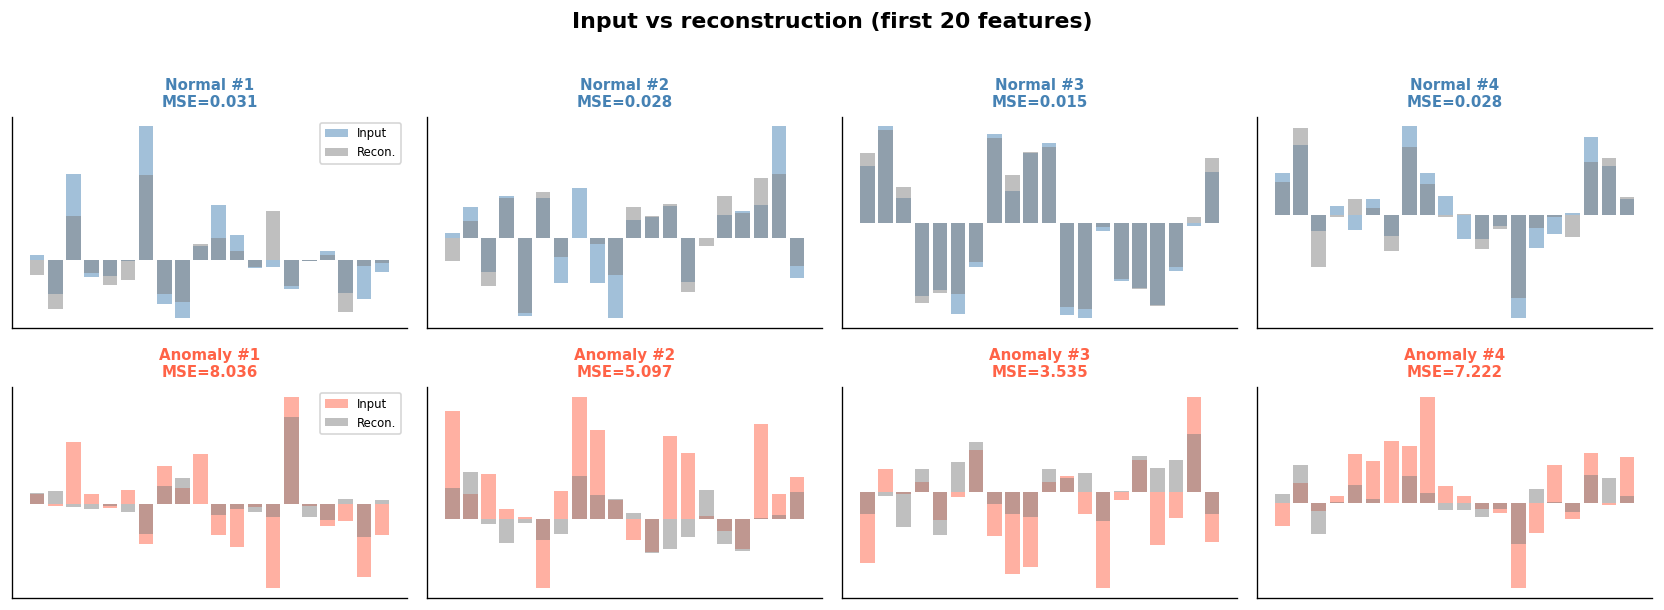

In [14]:
ae.eval()
with torch.no_grad():
    X_hat, _ = ae(X_test_t)
X_hat_np = X_hat.cpu().numpy()

idx_normal = np.where(y_test == 0)[0][:4]
idx_anom   = np.where(y_test == 1)[0][:4]

fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for row, (indices, label, color) in enumerate([(idx_normal, 'Normal', 'steelblue'),
                                                (idx_anom,   'Anomaly', 'tomato')]):
    for col, idx in enumerate(indices):
        ax = axes[row, col]
        x    = X_test[idx]
        xhat = X_hat_np[idx]
        feat = np.arange(len(x))
        ax.bar(feat, x,    alpha=0.5, color=color,   label='Input')
        ax.bar(feat, xhat, alpha=0.5, color='gray',  label='Recon.')
        err = np.mean((x - xhat)**2)
        ax.set_title(f'{label} #{col+1}\nMSE={err:.3f}', fontsize=9, color=color, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.legend(fontsize=7)

plt.suptitle('Input vs reconstruction (first 20 features)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/reconstructions.png', bbox_inches='tight')
plt.show()

## 9 · Summary and Limitations

| | Vanilla AE | VAE |
|---|---|---|
| Latent space | Deterministic | Stochastic (Gaussian) |
| Training objective | MSE only | ELBO = MSE + KL |
| Anomaly score | Reconstruction error | Recon + KL divergence |
| Latent structure | Unregularised | Smooth, continuous |
| Generative capability | No | Yes |
| Sensitivity | High (can overfit noise) | More robust via regularisation |

### Key limitations of AE-based anomaly detection

1. **Threshold sensitivity:** results depend heavily on the chosen $\tau$.
2. **Reconstruction of anomalies:** if anomalies are similar to training data in most dimensions but differ in few, they may still reconstruct well.
3. **No explicit density model:** the AE does not provide a true probability estimate.
4. **Curse of dimensionality in score space:** reconstruction error is an average over all features; feature-wise errors can be more informative.

### Extensions

- **β-VAE:** increase the KL weight β to encourage a more disentangled, compact prior.
- **Memory-augmented AE (MemAE):** augment the bottleneck with a memory module that forces the network to use prototypical patterns, making it harder to reconstruct anomalies.
- **DAGMM:** combine AE compression with a Gaussian Mixture Model on the latent space for an explicit density estimate.

---
*Next: Notebook 2 — LSTM Autoencoders for temporal anomaly detection.*

## Exercises

1. **Bottleneck exploration:** Re-run the latent dimension sweep with an anomaly contamination rate of 20% in the training data. What happens to the AUC curve?
2. **Score combination:** Try the combined score $\alpha \cdot \text{recon} + (1-\alpha) \cdot \text{KL}$ for the VAE and sweep $\alpha \in [0, 1]$. Report the best $\alpha$ by AUC-ROC.
3. **Feature-level scores:** Instead of averaging the reconstruction error across features, compute a per-feature reconstruction error matrix. Which features are most discriminative?
4. **Contaminated training:** Retrain the AE with 5% anomalies mixed into the training set. How much does AUC degrade? Propose a mitigation strategy.
5. **Real dataset:** Apply the VAE to the [KDD Cup 99](http://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html) or [Credit Card Fraud](https://www.kaggle.com/mlg-ulb/creditcardfraud) dataset and compare against Isolation Forest from Module 2.